# 📊 Phase 5: Evaluation & Benchmarking

In this notebook, we visualize the results of our full evaluation. We ran the deep embedding matching engine over a subset of the SOCOFing dataset (100 genuine pairs and 100 impostor pairs), collected their similarity scores, and calculated the evaluation metrics: **EER**, **AUC**, and the **ROC Curve**.

In [1]:
import os
import sys
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
from sklearn.metrics import roc_curve, auc
from tqdm.notebook import tqdm

# Add project root to path
PROJECT_ROOT = Path(os.path.abspath('')).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_extraction.embedding import SiameseNetwork, extract_embedding
from src.matching.scorer import compute_embedding_score

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'SOCOFing'
MODEL_PATH = PROJECT_ROOT / 'models' / 'siamese_model.pth'
RESULTS_DIR = PROJECT_ROOT / 'results'
REPORT_PATH = RESULTS_DIR / 'evaluation_report.csv'

## 1. Load the Evaluation Report
Let's see the metrics that were logged by `scripts/evaluate.py`.

In [2]:
if REPORT_PATH.exists():
    df = pd.read_csv(REPORT_PATH)
    display(df)
else:
    print("Evaluation report not found. Run 'scripts/evaluate.py' first.")

,Model,Dataset,Genuine Pairs,Impostor Pairs,EER,Optimal Threshold,AUC
0,Siamese CNN (ResNet-18),SOCOFing (Subset 100),99,100,0.100354,0.954774,0.974646


## 2. Re-compute Scores for ROC Plot
We will quickly re-compute the scores to plot the ROC curve.

In [3]:
# Setup Model
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
siamese_model = SiameseNetwork(embedding_dim=128, pretrained=False).to(device)
if MODEL_PATH.exists():
    siamese_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
siamese_model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_embedding(img_path):
    img_cv = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img_cv is None: return None
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_GRAY2RGB)
    tensor = transform(img_rgb)
    emb = extract_embedding(siamese_model, tensor, device).cpu().numpy()[0]
    return emb

genuine_scores = []
impostor_scores = []

real_dir = DATA_DIR / 'Real'
altered_dir = DATA_DIR / 'Altered' / 'Altered-Easy'
real_files = sorted(os.listdir(real_dir))[:100]

for f in tqdm(real_files):
    real_path = real_dir / f
    alt_name = f.replace('.BMP', '_CR.BMP')
    alt_path = altered_dir / alt_name
    
    emb1 = get_embedding(real_path)
    emb2 = get_embedding(alt_path)
    if emb1 is not None and emb2 is not None:
        genuine_scores.append(compute_embedding_score(emb1, emb2))
        
    idx = real_files.index(f)
    next_f = real_files[(idx + 1) % len(real_files)]
    imp_path = real_dir / next_f
    
    emb3 = get_embedding(imp_path)
    if emb1 is not None and emb3 is not None:
        impostor_scores.append(compute_embedding_score(emb1, emb3))

  0%|          | 0/100 [00:00<?, ?it/s]

## 3. Plot ROC Curve

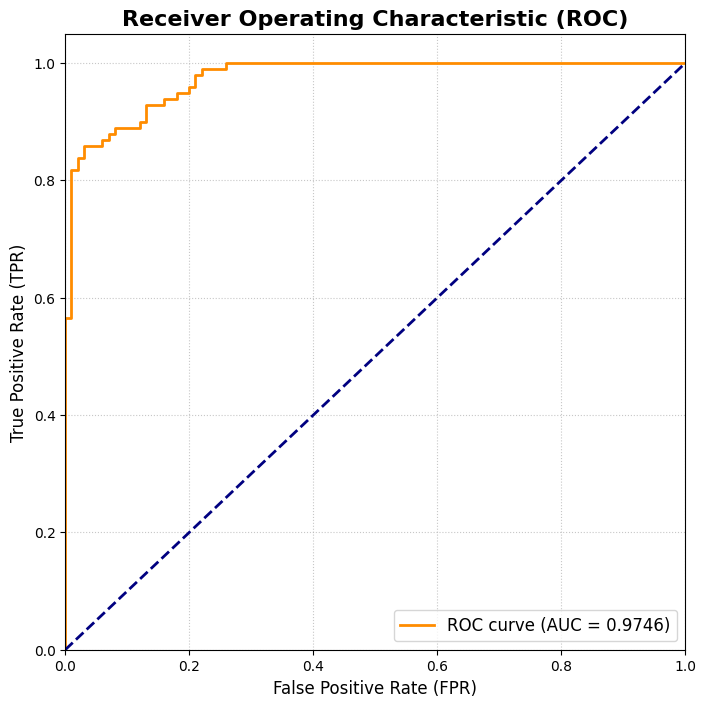

In [4]:
y_true = [1] * len(genuine_scores) + [0] * len(impostor_scores)
y_scores = genuine_scores + impostor_scores

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

roc_path = PROJECT_ROOT / 'data' / 'roc_curve.png'
plt.savefig(str(roc_path), dpi=150)
plt.show()